# POWER ANALYSIS
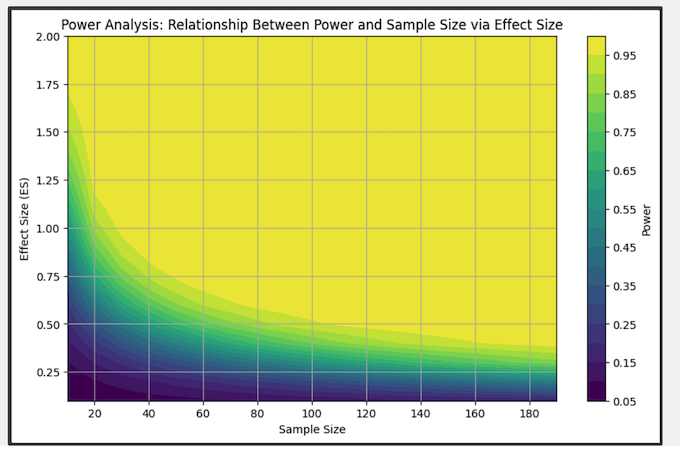

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy.stats as stats
import statsmodels.stats.power as smp

### Hypothesis Testing Errors

A) False Positives – Type I errors: null hypothesis incorrectly rejected. Probability denoted as \$\alpha$.

B) False Negative – Type II errors: null hypothesis incorrectly accepted. Probability denoted as $\beta$.

**Power of the test**: ability to detect a true difference or effect when it exists: 1- $\beta$.

### Power Analysis
Technique to determine sample size of minimum detectable effect size needed for a desired level of statistical power.

1. Effect size (ES): magnitude of true effect or difference in the population.<br>
Cohen's *d*: $\frac{\mu_1 - \mu_2}{\sigma}$ <br>
small- 0.2; medium- 0.5; large- >= 0.8

2. Significance level ($\alpha$): probability of type I error (false positive rate).

3. Power (1 - $\beta$): probability of **avoiding** type II error (correctly rejecting null hypothesis).

4. Sample size: number of observations or participants included in study.

Example:

In [4]:

# Parameters for power analysis
effect_size = 0.5  # Desired effect size (Cohen's d)
alpha = 0.05  # Significance level (Type I error rate)
power = 0.8  # Desired power (1 - Type II error rate)

# Perform power analysis
power_analysis = smp.tt_ind_solve_power(effect_size=effect_size, nobs1=None, alpha=alpha, power=power, ratio=1, alternative='two-sided')

# Print the required sample size
print("Required Sample Size:", round(power_analysis))

# Perform power analysis for a range of sample sizes
sample_sizes = np.arange(10, 101, 10)
for n in sample_sizes:
    power_analysis = smp.tt_ind_solve_power(effect_size=effect_size, nobs1=n, alpha=alpha, power=None, ratio=1, alternative='two-sided')
    print("Sample Size:", n, "- Power:", round(power_analysis, 2))



Required Sample Size: 64
Sample Size: 10 - Power: 0.19
Sample Size: 20 - Power: 0.34
Sample Size: 30 - Power: 0.48
Sample Size: 40 - Power: 0.6
Sample Size: 50 - Power: 0.7
Sample Size: 60 - Power: 0.78
Sample Size: 70 - Power: 0.84
Sample Size: 80 - Power: 0.88
Sample Size: 90 - Power: 0.92
Sample Size: 100 - Power: 0.94


result 0.185095655378675
result 0.33793902806643866
result 0.4778965200281764
result 0.5981468933495994
result 0.69689340057952
result 0.775265874618152
result 0.8358222589469667
result 0.8816024847721201
result 0.9155872129575743
result 0.9404271933839894
result 0.9583410217154508
result 0.9711087736846405
result 0.9801142960582472
result 0.9864071934230251
result 0.9907677057451855
result 0.9937662186820053
result 0.9958138093147724
result 0.9972031305508973


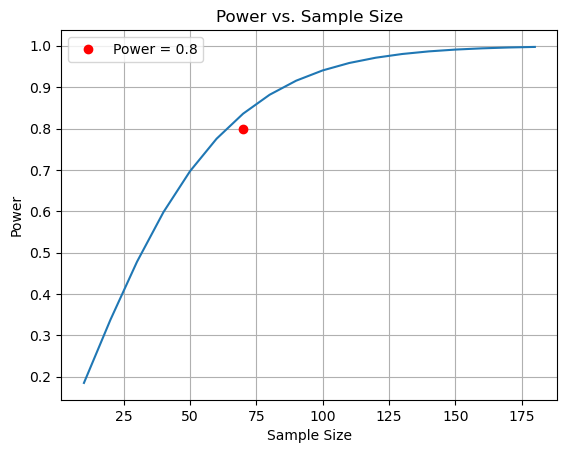

Sample Size for Power = 0.8: 70


In [5]:
# from statsmodels.stats.power import TTestIndPower

# Define parameters for the power analysis
effect_size = 0.5   # desired effect size (Cohen's d)
alpha = 0.05       # significance level
power_values = np.linspace(0.1, 0.9, num=9)  # range of power values to calculate
sample_sizes = np.arange(10, 190, step=10)  # range of sample sizes to consider

# Perform power analysis and collect results
results = []
sample_size_80_power = None  # Initialize variable
for n in sample_sizes:
    power_analysis = smp.TTestIndPower()
    result = power_analysis.solve_power(effect_size=effect_size, alpha=alpha, power=None, nobs1=n)
    results.append(result)
    print('result', result)
    # Update sample_size_80_power if power reaches 0.8
    if result >= 0.8 and sample_size_80_power is None:
        sample_size_80_power = n

# Generate the power vs. sample size plot
plt.plot(sample_sizes, results)
plt.xlabel("Sample Size")
plt.ylabel("Power")
plt.title("Power vs. Sample Size")
plt.grid(True)

# Find the specific sample size for power = 0.8
target_power = 0.8
if sample_size_80_power is not None:
    plt.plot(sample_size_80_power, target_power, 'ro', label=f"Power = {target_power}")
    plt.legend()
    plt.show()
    print(f"Sample Size for Power = {target_power}: {sample_size_80_power}")
else:
    print(f"No sample size achieved a power of {target_power}.")


sample_sizepower [ 10  20  30  40  50  60  70  80  90 100 110 120 130 140 150 160 170 180] [0.185095655378675, 0.33793902806643866, 0.4778965200281764, 0.5981468933495994, 0.69689340057952, 0.775265874618152, 0.8358222589469667, 0.8816024847721201, 0.9155872129575743, 0.9404271933839894, 0.9583410217154508, 0.9711087736846405, 0.9801142960582472, 0.9864071934230251, 0.9907677057451855, 0.9937662186820053, 0.9958138093147724, 0.9972031305508973]


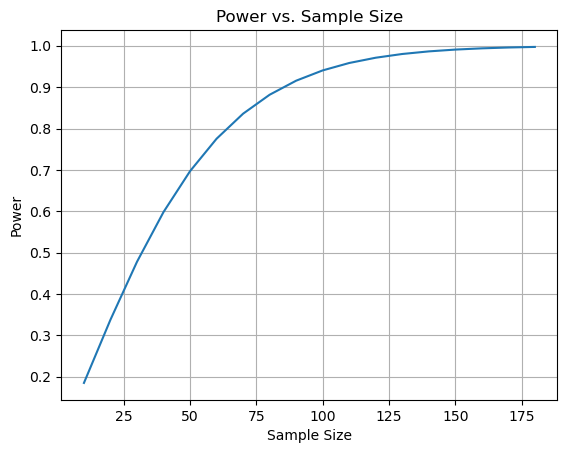

In [6]:

# Define parameters for the power analysis
effect_size = 0.5   # desired effect size (Cohen's d)
alpha = 0.05       # significance level
power_values = np.linspace(0.1, 0.9, num=9)  # range of power values to calculate
sample_sizes = np.arange(10, 190, step=10)  # range of sample sizes to consider

# Perform power analysis and collect results
results = []
for n in sample_sizes:
    power_analysis = smp.TTestIndPower()
    result = power_analysis.solve_power(effect_size=effect_size, alpha=alpha, power=None, nobs1=n)
    results.append(result)

print('sample_size' 'power', sample_sizes,results )
    
# Generate the power vs. sample size plot
plt.plot(sample_sizes, results)
plt.xlabel("Sample Size")
plt.ylabel("Power")
plt.title("Power vs. Sample Size")
plt.grid(True)
plt.show()

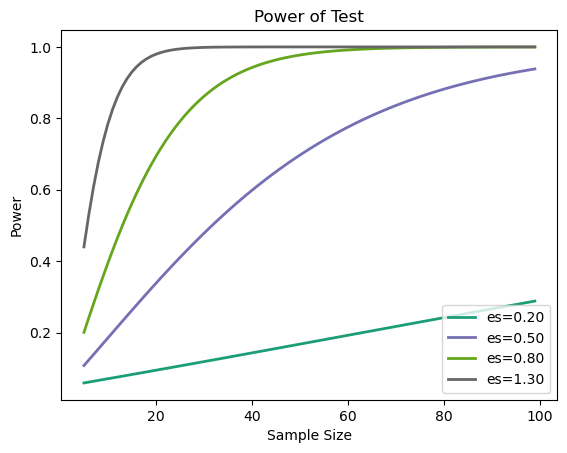

In [7]:

# power analysis varying parameters
effect_sizes = np.array([0.2, 0.5, 0.8,1.3])
sample_sizes = np.array(range(5, 100))
  
# plot power curves
obj = smp.TTestIndPower()
obj.plot_power(dep_var='nobs', nobs=sample_sizes,
               effect_size=effect_sizes)
plt.xlabel("Sample Size")
plt.ylabel("Power") 
plt.show()


### Sensitivity, Specitivity, PPV, NPV

1. Sensitivity (Recall in ML, Power): proportion of positives correctly identified. Ex: probability of a positive test given that the the subject is ill.
$$Sensitivity = \frac{TP}{TP + FN}$$

2. Specificity: proportion of negatives correctly identified. Ex: probability of a negative test given that the subject is well.
$$Specificity = \frac{TN}{FP + TN}$$

3. Positive Predictive Value (PPV)(Precision in ML): probability a positive result will be correct. Ex: proportion of patients w/positive results who are correctly diagnosed.
$$PPV = \frac{TP}{TP + FP}$$

4.  Negative Predictive Value (PPV): probability a negative result will be correct. Ex: proportion of patients w/negative results who are correctly diagnosed.
$$NPV = \frac{TN}{TN + FN}$$

In ML, we also have:
$$Accuracy = \frac{TP + TN}{P + N}$$
$$F1 = 2*\frac{Precision * Recall}{Precision + Recall} = 2*\frac{PPV * Sensitivity}{PPV + Sensitivity} $$

**PPV and NPV are affected by *prevalence*: proportion of a population affected by a disease.**

- False positive rate $\alpha$ (Type I error) = $1 - Specificity = \frac{FP}{FP + TN}$
- False negative rate $\beta$ (Type II error) = $1 - Sensitivity = \frac{FN}{FN + TP}$
- Positive likelihood ratio = $\frac{Sensitivity}{1 - Specificity}$
- Negative likelihood ratio = $\frac{1 - Sensitivity}{Specificity}$

Example: In a study evaluating the performance of a diagnostic test for a certain disease, a group of 100 patients was tested. Out of these, 40 patients were known to have the disease (true positives) and 60 patients were known to be disease-free (true negatives). The test provides a continuous score ranging from 0 to 1, where a higher score indicates a higher likelihood of having the disease. Using the test results, calculate the sensitivity, specificity, PPV, NPV, and plot the ROC curve (True/False positives relationship).


Sensitivity: 0.45
Specificity: 0.45
PPV: 0.35294117647058826
NPV: 0.5510204081632653
AUC: 0.495


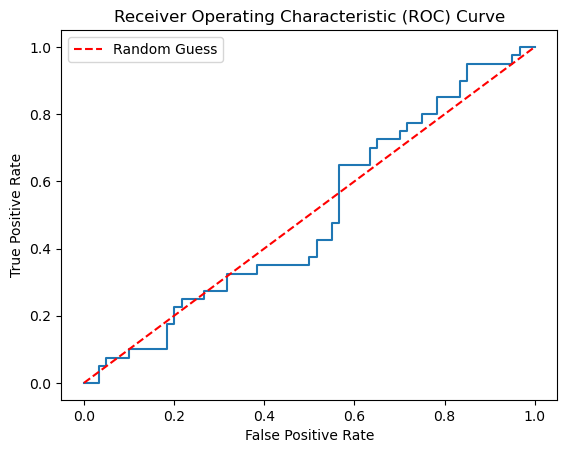

In [110]:
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay

# Generate example data
np.random.seed(123)
true_labels = np.array([1] * 40 + [0] * 60)  # True labels: 40 positive (1) and 60 negative (0)
predicted_scores = np.random.rand(100)  # Randomly generated predicted scores

# Calculate sensitivity, specificity, PPV, NPV
threshold = 0.5  # Threshold for classification
predicted_labels = np.where(predicted_scores >= threshold, 1, 0)
true_positives = np.sum(np.logical_and(predicted_labels == 1, true_labels == 1))
true_negatives = np.sum(np.logical_and(predicted_labels == 0, true_labels == 0))
false_positives = np.sum(np.logical_and(predicted_labels == 1, true_labels == 0))
false_negatives = np.sum(np.logical_and(predicted_labels == 0, true_labels == 1))

sensitivity = true_positives / (true_positives + false_negatives)
specificity = true_negatives / (true_negatives + false_positives)
ppv = true_positives / (true_positives + false_positives)
npv = true_negatives / (true_negatives + false_negatives)

# Perform ROC analysis
fpr, tpr, thresholds = roc_curve(true_labels, predicted_scores)
auc = roc_auc_score(true_labels, predicted_scores)

# Print evaluation metrics
print("Sensitivity:", sensitivity)
print("Specificity:", specificity)
print("PPV:", ppv)
print("NPV:", npv)
print("AUC:", auc)

# Plot ROC curve
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], 'r--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()


In [114]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

accuracy = accuracy_score(true_labels, predicted_labels)
print(f"Accuracy: {accuracy}")

recall = recall_score(true_labels, predicted_labels, pos_label=1)
print(f"Recall: {recall}")

precision = precision_score(true_labels, predicted_labels, pos_label=1)
print(f"Precision: {precision}")

f1 = f1_score(true_labels, predicted_labels, pos_label=1)
print(f"F1-score: {f1}")


Accuracy: 0.45
Recall: 0.45
Precision: 0.35294117647058826
F1-score: 0.39560439560439564
